# Block diagrams of the `tformer.py` radar attention Encoder

Four ways to get a diagram out of the PyTorch model, one per cell:

| Cell | Tool | Install | Best for |
|---|---|---|---|
| 2 | `torchview` | `pip install torchview graphviz` + system graphviz | **publication-quality block diagram** |
| 3 | `torch.fx` | built into torch (`pip install pydot`) | exact traced op graph |
| 4 | ONNX + Netron | `pip install onnx` | interactive inspection, shapes on edges |
| 5 | `torchinfo` | `pip install torchinfo` | tabular shape/param audit |
| 6 | manual graphviz | `pip install graphviz` | the FP16 firmware schedule (bonus) |

**Caveat that applies to cells 2-5:** they trace the *training* model. The folded
constants (`1/sqrt(d_model)` into `Wq`, `exp(gate)/L` into `Wv`, `1/12` into `POOL`)
only exist after `Weights.from_torch`, and `forward_fp16` is pure NumPy so no tracer
can see it. Cell 6 draws that side by hand.


In [2]:
# =====================================================================
# Cell 1 - load tformer.py from the same folder (no code duplication)
# =====================================================================
import importlib, importlib.util, sys, types
from pathlib import Path

HERE = Path.cwd()
if not (HERE / "tformer.py").exists():                 # notebook run elsewhere
    for cand in [Path(__file__).parent if "__file__" in dir() else HERE, *HERE.parents]:
        if (cand / "tformer.py").exists():
            HERE = cand
            break
assert (HERE / "tformer.py").exists(), f"tformer.py not found from {Path.cwd()}"

# tformer.py does `import radar_scene as rs` at module level.  If the real
# module is not importable, install a minimal stub: the diagrams only need the
# three constants that appear in Encoder's signature.
if importlib.util.find_spec("radar_scene") is None:
    _rs = types.ModuleType("radar_scene")
    _rs.N_FEATURES, _rs.N_FRAMES, _rs.N_ANT = 32, 12, 12
    _rs.CLASSES = ("static", "approaching", "receding", "crossing")
    def _unavailable(*a, **k):
        raise NotImplementedError("stub radar_scene: training/export unavailable")
    _rs.steering_matrix = _unavailable
    _rs.make_sequence = _unavailable
    sys.modules["radar_scene"] = _rs
    print("radar_scene not importable -> using stub (diagrams only, no training)")

if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import tformer
importlib.reload(tformer)                              # pick up edits to the file
from tformer import Encoder, Weights, D_MODEL, N_CLASSES, TILE_M, TILE_N

import torch

FRAMES, N_FEATURES = 12, 32
LAYERS, D_FF = 2, 48

torch.manual_seed(0)
model = Encoder(n_features=N_FEATURES, frames=FRAMES, layers=LAYERS, d_ff=D_FF).eval()
EXAMPLE = torch.randn(1, FRAMES, N_FEATURES)           # (batch, frames, features)

print(f"loaded {tformer.__file__}")
print(f"d_model={D_MODEL} d_ff={D_FF} layers={LAYERS} classes={N_CLASSES} "
      f"tile={TILE_M}x{TILE_N}")
print(f"input  {tuple(EXAMPLE.shape)} -> logits {tuple(model(EXAMPLE).shape)}")
print(f"torch parameters: {sum(p.numel() for p in model.parameters()):,}")


loaded /home/uic52463/hdd2/daro/ibex-ci/isolde/sw/radar_attention/tformer.py
d_model=16 d_ff=48 layers=2 classes=4 tile=12x16
input  (1, 12, 32) -> logits (1, 4)
torch parameters: 5,890


wrote /home/uic52463/hdd2/daro/ibex-ci/isolde/sw/radar_attention/encoder_torchview.svg


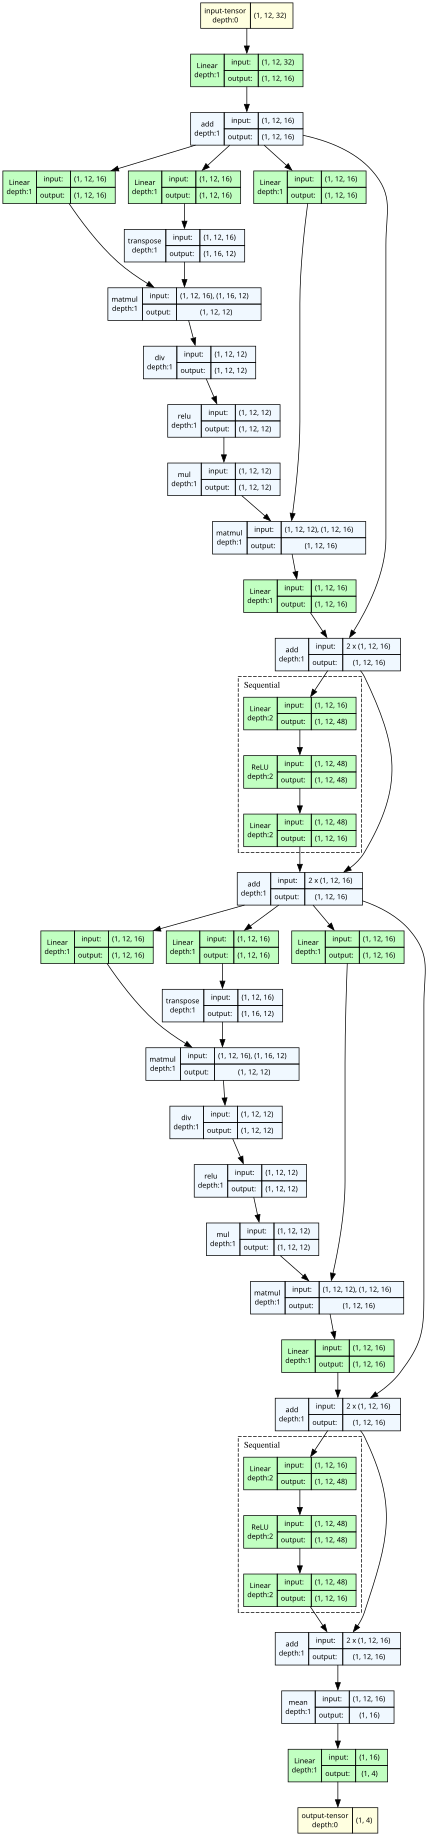

In [3]:
# =====================================================================
# Cell 2 - OPTION 1: torchview  (closest to a real block diagram)
#   pip install torchview graphviz      # plus the SYSTEM graphviz binaries:
#   apt-get install graphviz  /  brew install graphviz  /  conda install graphviz
# =====================================================================
from torchview import draw_graph

# depth=1 -> block level (proj / attn / mlp / head)
# depth=3 -> inside each block (Q, K, V, matmul, relu, residual add)
DEPTH = 3

graph = draw_graph(
    model,
    input_size=(1, FRAMES, N_FEATURES),
    depth=DEPTH,
    expand_nested=True,
    graph_name="radar_encoder",
    roll=True,                    # collapse the repeated layers
    save_graph=True,
    directory=str(HERE),
    filename="encoder_torchview",
)
graph.visual_graph.format = "svg"
graph.visual_graph.render(str(HERE / "encoder_torchview"), cleanup=True)
print("wrote", HERE / "encoder_torchview.svg")

graph.visual_graph          # renders inline


opcode         name         target                             args                     kwargs
-------------  -----------  ---------------------------------  -----------------------  ------------------
placeholder    x            x                                  ()                       {}
call_function  getattr_1    <built-in function getattr>        (x, 'shape')             {}
call_function  getitem      <built-in function getitem>        (getattr_1, 1)           {}
call_module    proj         proj                               (x,)                     {}
get_attr       pos          pos                                ()                       {}
call_function  add          <built-in function add>            (proj, pos)              {}
call_module    attn_0_q     attn.0.q                           (add,)                   {}
call_module    attn_0_k     attn.0.k                           (add,)                   {}
call_module    attn_0_v     attn.0.v                           (add,) 

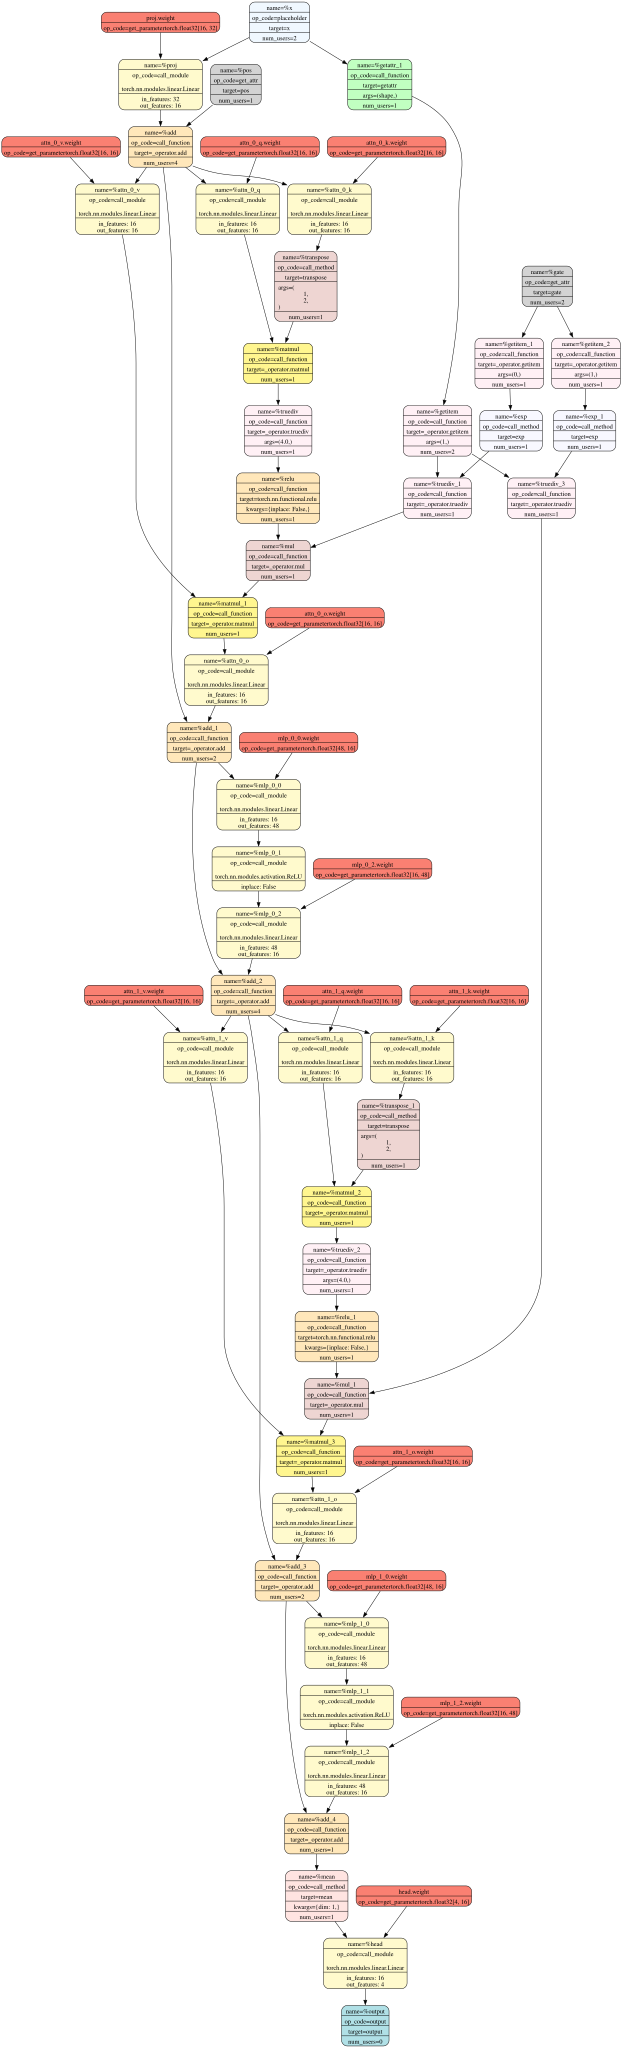

In [4]:
# =====================================================================
# Cell 3 - OPTION 2: torch.fx  (the actual built-in tracer)
#   pip install pydot         # for the SVG; the text listing needs nothing
# =====================================================================
from torch.fx import symbolic_trace

gm = symbolic_trace(model)

# Text listing of every traced op - this IS the graph, no rendering needed.
gm.graph.print_tabular() if hasattr(gm.graph, "print_tabular") else print(gm.graph)

print("\n--- generated forward ---\n")
print(gm.code)

# Note: `length = x.shape[1]` is traced as a live node, so `exp(gate)/length`
# appears as real arithmetic rather than a constant.  The `zip(self.attn,
# self.mlp)` loop is unrolled at trace time -> both layers appear explicitly.

try:
    from torch.fx.passes.graph_drawer import FxGraphDrawer
    dot = FxGraphDrawer(gm, "radar_encoder").get_dot_graph()
    dot.write_svg(str(HERE / "encoder_fx.svg"))
    print("\nwrote", HERE / "encoder_fx.svg")
    from IPython.display import SVG, display
    display(SVG(filename=str(HERE / "encoder_fx.svg")))
except ImportError as exc:
    print("\nSVG skipped (pip install pydot):", exc)


In [11]:
# =====================================================================
# Cell 4 - OPTION 3: ONNX export -> open in Netron
#   pip install onnx            # optional: pip install netron
# =====================================================================
onnx_path = HERE / "encoder.onnx"

torch.onnx.export(
    model,
    EXAMPLE,
    str(onnx_path),
    input_names=["window"],
    output_names=["logits"],
    dynamic_axes={"window": {0: "batch"}, "logits": {0: "batch"}},
    opset_version=17,
)
print("wrote", onnx_path)

try:
    import onnx
    m = onnx.load(str(onnx_path))
    onnx.checker.check_model(m)
    print(f"checked OK - {len(m.graph.node)} nodes")
    print("ops:", sorted({n.op_type for n in m.graph.node}))
except ImportError:
    print("pip install onnx to validate")

# View it:  (a) drag encoder.onnx onto https://netron.app
#           (b) or run the next two lines for a local server
import netron; netron.start(str(onnx_path))


/tmp/ipykernel_70332/3911163811.py:7: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0924 15:44:33.875000 70332 site-packages/torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0924 15:44:34.273000 70332 site-packages/torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::nms
W0924 15:44:34.274000 70332 site-packages/torch/onnx/_inter

[torch.onnx] Obtain model graph for `Encoder([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Encoder([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/home/uic52463/hdd1/miniconda3/envs/torch_env/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/uic52463/hdd1/miniconda3/envs/torch_env/lib/python3.11/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/uic52463/hdd1/miniconda3/envs/torch_env/lib/python3.11/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
wrote /home/uic52463/hdd2/daro/ibex-ci/isolde/sw/radar_attention/encoder.onnx
checked OK - 32 nodes
ops: ['Add', 'Div', 'Gemm', 'MatMul', 'ReduceMean', 'Relu', 'Transpose']


('localhost', 8080)

In [8]:
# =====================================================================
# Cell 5 - OPTION 4: torchinfo  (tabular, not graphical)
#   pip install torchinfo
# =====================================================================
from torchinfo import summary

summary(
    model,
    input_size=(1, FRAMES, N_FEATURES),
    depth=4,
    col_names=["input_size", "output_size", "num_params", "mult_adds"],
    row_settings=["var_names"],
)


Layer (type (var_name))                  Input Shape               Output Shape              Param #                   Mult-Adds
Encoder (Encoder)                        [1, 12, 32]               [1, 4]                    194                       --
├─Linear (proj)                          [1, 12, 32]               [1, 12, 16]               512                       512
├─ModuleList (attn)                      --                        --                        (recursive)               --
│    └─ModuleDict (0)                    --                        --                        --                        --
│    │    └─Linear (q)                   [1, 12, 16]               [1, 12, 16]               256                       256
│    │    └─Linear (k)                   [1, 12, 16]               [1, 12, 16]               256                       256
│    │    └─Linear (v)                   [1, 12, 16]               [1, 12, 16]               256                       256
│    │    └─L

In [9]:
# =====================================================================
# Cell 5b - cross-check the torch model against the exported FP16 weights
# =====================================================================
w = Weights.from_torch(model, frames=FRAMES)

torch_params = sum(p.numel() for p in model.parameters())
export_params = int(w.parameter_count())
counts = tformer.launch_counts(w, frames=FRAMES, n_features=N_FEATURES)

print(f"torch parameters      : {torch_params:,}")
print(f"exported FP16 entries : {export_params:,}   "
      f"({export_params * 2:,} bytes)")
print("  difference is the padded POOL/head tiles and the dropped `gate`,")
print("  which is folded into wv rather than exported.")
print(f"RedMulE launches      : {counts['launches']}")
print(f"barriers              : {counts['barriers']}")
for name, arr in [("proj", w.proj), ("pos", w.pos), ("pool", w.pool), ("head", w.head)]:
    print(f"  {name:5s} {arr.shape}")
for key in ("wq", "wk", "wv", "wo", "w1", "w2"):
    print(f"  l0.{key:3s} {w.layers[0][key].shape}")


torch parameters      : 5,890
exported FP16 entries : 6,272   (12,544 bytes)
  difference is the padded POOL/head tiles and the dropped `gate`,
  which is folded into wv rather than exported.
RedMulE launches      : 28
barriers              : 20
  proj  (32, 16)
  pos   (12, 16)
  pool  (12, 16)
  head  (16, 16)
  l0.wq  (16, 16)
  l0.wk  (16, 16)
  l0.wv  (16, 16)
  l0.wo  (16, 16)
  l0.w1  (3, 16, 16)
  l0.w2  (3, 16, 16)


wrote /home/uic52463/hdd2/daro/ibex-ci/isolde/sw/radar_attention/encoder_firmware.svg


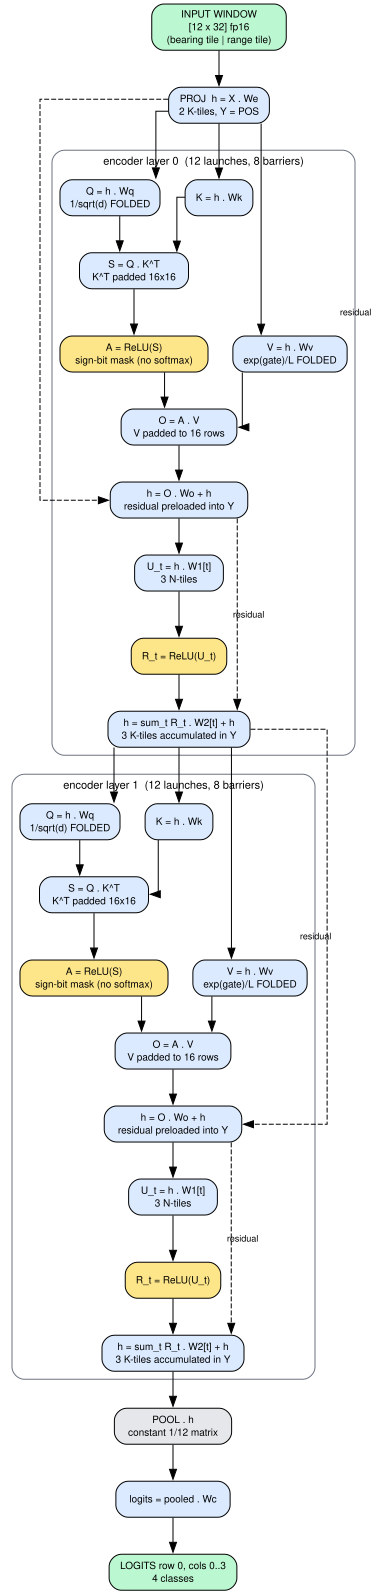

In [10]:
# =====================================================================
# Cell 6 - BONUS: the FP16 firmware schedule, drawn by hand
#   No tracer can see this: forward_fp16 is pure NumPy, and the folded
#   constants only exist after Weights.from_torch.
#   pip install graphviz  (+ system graphviz)
# =====================================================================
from graphviz import Digraph

g = Digraph("firmware", graph_attr=dict(rankdir="TB", splines="ortho",
                                        fontname="Helvetica", nodesep="0.35"),
            node_attr=dict(shape="box", style="rounded,filled",
                           fontname="Helvetica", fontsize="10"),
            edge_attr=dict(fontname="Helvetica", fontsize="9"))

GEMM, ACT, CONST, IO = "#dbeafe", "#fde68a", "#e5e7eb", "#bbf7d0"

g.node("x", "INPUT WINDOW\n[12 x 32] fp16\n(bearing tile | range tile)", fillcolor=IO)
g.node("proj", "PROJ  h = X . We\n2 K-tiles, Y = POS", fillcolor=GEMM)
g.edge("x", "proj")

prev = "proj"
for i in range(LAYERS):
    with g.subgraph(name=f"cluster_{i}") as c:
        c.attr(label=f"  encoder layer {i}  (12 launches, 8 barriers)  ",
               style="rounded", color="#6b7280", fontname="Helvetica", fontsize="11")
        c.node(f"q{i}", f"Q = h . Wq\n1/sqrt(d) FOLDED", fillcolor=GEMM)
        c.node(f"k{i}", "K = h . Wk", fillcolor=GEMM)
        c.node(f"v{i}", "V = h . Wv\nexp(gate)/L FOLDED", fillcolor=GEMM)
        c.node(f"s{i}", "S = Q . K^T\nK^T padded 16x16", fillcolor=GEMM)
        c.node(f"a{i}", "A = ReLU(S)\nsign-bit mask (no softmax)", fillcolor=ACT)
        c.node(f"o{i}", "O = A . V\nV padded to 16 rows", fillcolor=GEMM)
        c.node(f"h{i}", "h = O . Wo + h\nresidual preloaded into Y", fillcolor=GEMM)
        c.node(f"u{i}", "U_t = h . W1[t]\n3 N-tiles", fillcolor=GEMM)
        c.node(f"r{i}", "R_t = ReLU(U_t)", fillcolor=ACT)
        c.node(f"f{i}", "h = sum_t R_t . W2[t] + h\n3 K-tiles accumulated in Y", fillcolor=GEMM)
        for a, b in [(f"q{i}", f"s{i}"), (f"k{i}", f"s{i}"), (f"s{i}", f"a{i}"),
                     (f"a{i}", f"o{i}"), (f"v{i}", f"o{i}"), (f"o{i}", f"h{i}"),
                     (f"h{i}", f"u{i}"), (f"u{i}", f"r{i}"), (f"r{i}", f"f{i}")]:
            c.edge(a, b)
    for tgt in (f"q{i}", f"k{i}", f"v{i}"):
        g.edge(prev, tgt)
    g.edge(prev, f"h{i}", label="residual", style="dashed", constraint="false")
    g.edge(f"h{i}", f"f{i}", label="residual", style="dashed", constraint="false")
    prev = f"f{i}"

g.node("pool", "POOL . h\nconstant 1/12 matrix", fillcolor=CONST)
g.node("head", "logits = pooled . Wc", fillcolor=GEMM)
g.node("out", "LOGITS row 0, cols 0..3\n4 classes", fillcolor=IO)
g.edge(prev, "pool"); g.edge("pool", "head"); g.edge("head", "out")

g.render(str(HERE / "encoder_firmware"), format="svg", cleanup=True)
print("wrote", HERE / "encoder_firmware.svg")
g
